
### INSURANCE CLAIM PROJECT

### Background:
Leveraging customer information is of paramount importance for most businesses. In the case of an insurance company, the attributes of customers can be crucial in making business decisions. Hence, knowing to explore and generate value out of such data can be an invaluable skill to have.
As a Data Scientist/Analyst in the Abuja Insurance company. The company wants to have a detailed understanding of the customer base for one of its Insurance Policy 'MediClaim'. The idea is to generate insights about the customers and answer a few key questions, by using the past dataset. The dataset 'abuja_Insurance' contains customers' details like age, sex, charges, etc.

### Objective:
Explore the dataset and extract insights from the data. The idea is for you to get comfortable with doing analysis in Python.
You are expected to do the following:
>  Explore the dataset and extract insights using Exploratory Data Analysis.
- Prove(or disprove) that the medical claims made by the people who smoke are greater than those who don't?
- Prove (or disprove) with that the BMI of females is different from that of males.
- Does the smoking habit of customers depend on their region?
- Is the mean BMI of women with no children, one child, and two children the same? 



#### Data Dictionary –
- Age - This is an integer indicating the age of the primary beneficiary (excluding those above 64 years, since they are generally covered by the government).
- Sex - This is the policy holder's gender, either male or female.
- BMI - This is the body mass index (BMI), which provides a sense of how over or underweight a person is relative to their height. BMI is equal to weight (in kilograms) divided by height (in meters) squared. An ideal BMI is within the range of 18.5 to 24.9.
- Children - This is an integer indicating the number of children/dependents covered by the insurance plan.
- Smoker - This is yes or no depending on whether the insured regularly smokes tobacco.
- Region - This is the beneficiary's place of residence in the U.S., divided into four geographic regions - northeast, southeast, southwest, or northwest.
- Charges - Individual medical costs billed to health insurance


### importing necesary libraries

In [2]:
#import libraries
import pandas as pd
import numpy as np

In [3]:
# data importing and reading in of Data sets
df = pd.read_csv('abuja_insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,21,female,16.000,1,no,northeast,3167.45585
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,52,female,46.750,5,no,southeast,12592.53450
1335,54,female,47.410,0,yes,southeast,63770.42801
1336,37,female,47.600,2,yes,southwest,46113.51100


In [4]:
#assess the dataset's description
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.682687,1.094918,13270.422265
std,14.049960,6.145674,1.205493,12110.011237
min,18.000000,14.000000,0.000000,1121.873900
25%,27.000000,26.315000,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.700000,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
#assess the dataset for data duplicates
df.duplicated().sum()

1

In [6]:
#assess the dataset for missing data
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### EXPLORATTORY DATA ANALYSIS

### Univariate Analysis

In [7]:
#importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

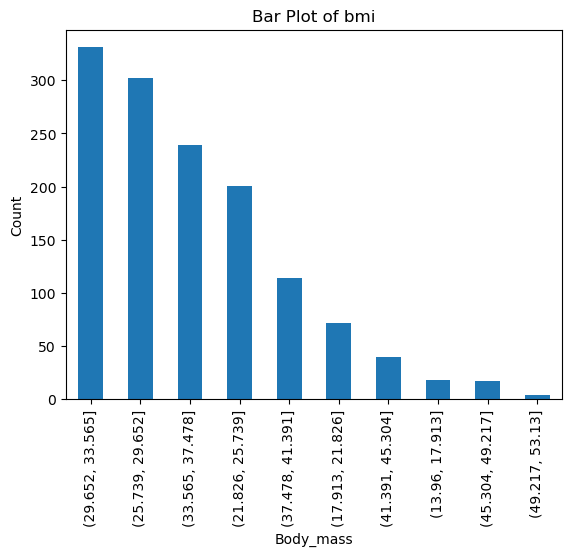

In [8]:
#univariate analysis for the body mass index feature
df['bmi'].value_counts(bins=10).plot.bar()
plt.title('Bar Plot of bmi')
plt.xlabel('Body_mass')
plt.ylabel('Count')
plt.show()


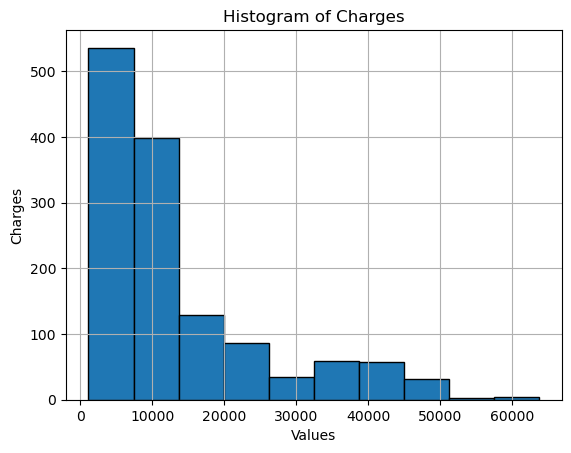

In [9]:
#univariate analysis for the charges feature
df['charges'].hist(bins=10, edgecolor='black')
plt.title('Histogram of Charges')
plt.xlabel('Values')
plt.ylabel('Charges')
plt.show()


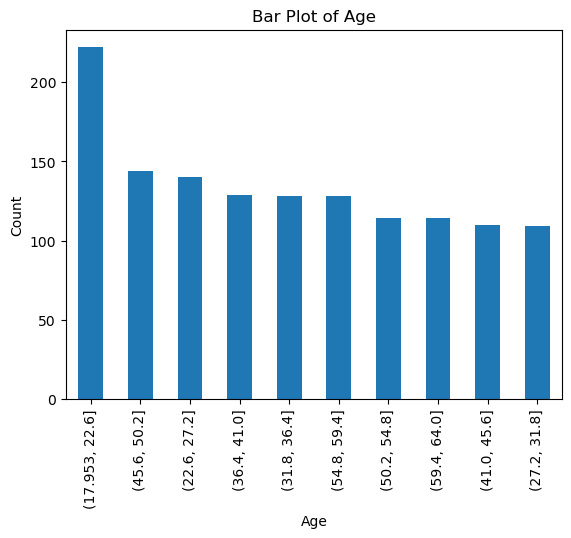

In [10]:
#univariate analysis for the age feature
df['age'].value_counts(bins=10).plot.bar()
plt.title('Bar Plot of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


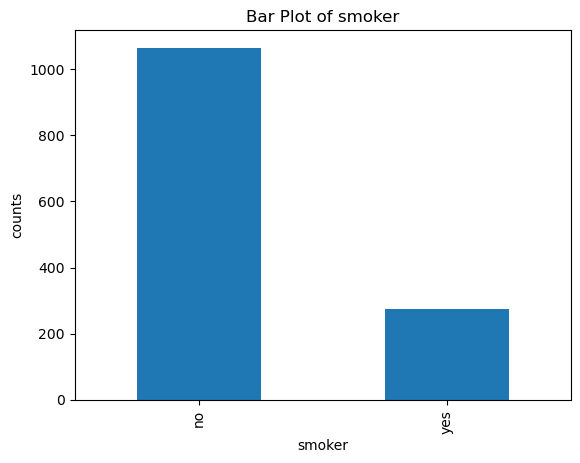

In [11]:
#univariate analysis of the smoker features
df['smoker'].value_counts().plot.bar()
plt.title('Bar Plot of smoker')
plt.xlabel('smoker')
plt.ylabel('counts')
plt.show()



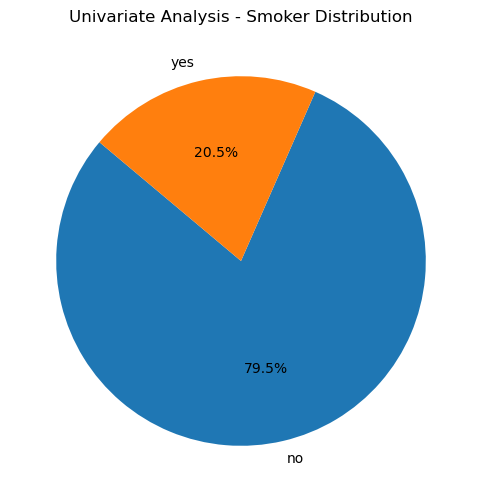

In [12]:
#univariate analysis of smoker features

# Select a categorical feature for univariate analysis
feature = 'smoker'  # Replace with your specific feature

# Count the unique values in the feature
value_counts = df[feature].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=140)
plt.title(f'Univariate Analysis - {feature.capitalize()} Distribution')

# Show the plot
plt.show()


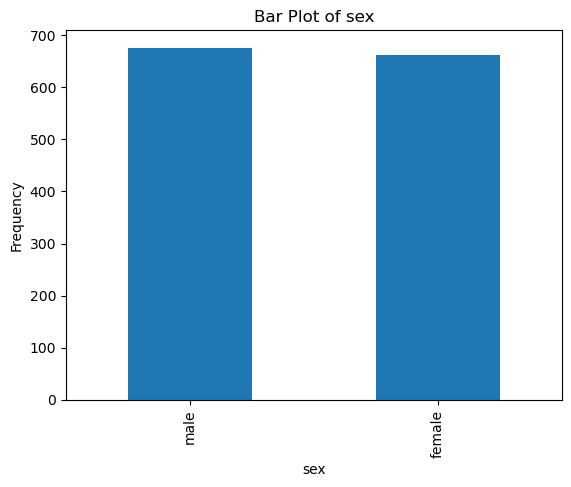

In [13]:
#graphical visualiation of the sex feature
df['sex'].value_counts().plot.bar()
plt.title('Bar Plot of sex')
plt.xlabel('sex')
plt.ylabel('Frequency')
plt.show()



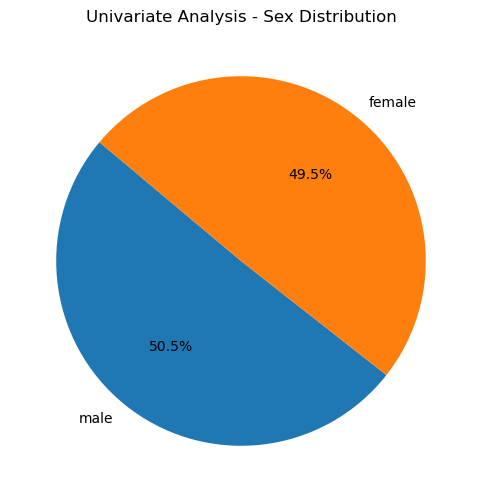

In [14]:
#graphical visualization of the sex features

# Select a categorical feature for univariate analysis
feature = 'sex'  # Replace with your specific feature

# Count the unique values in the feature
value_counts = df[feature].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=140)
plt.title(f'Univariate Analysis - {feature.capitalize()} Distribution')

# Show the plot
plt.show()


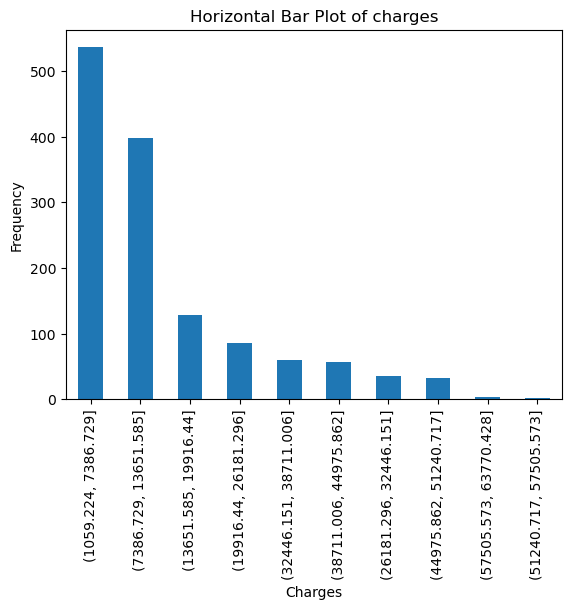

In [15]:
# graphical visualiation of the target label(charges feature)
df['charges'].value_counts(bins=10).plot.bar()
plt.title('Horizontal Bar Plot of charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()


### OBSERVATIONS

### Bivariate Analysis

In [16]:
import warnings
warnings.filterwarnings('ignore') 

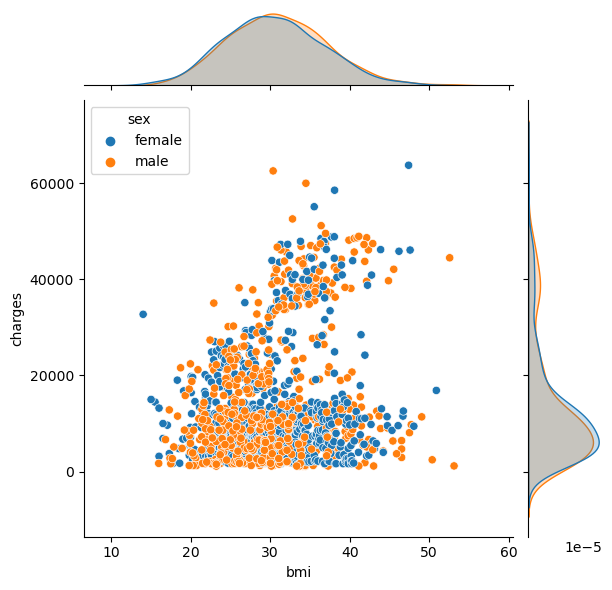

In [17]:
#jointplot exploring the relationship between the bmi vs charges features
sns.jointplot(df,x='bmi',y='charges',hue='sex')

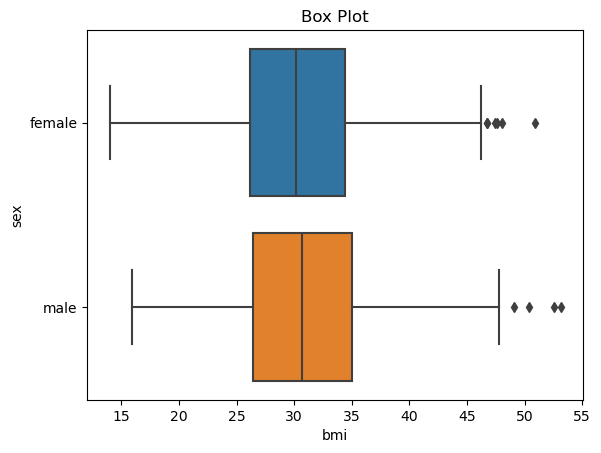

In [18]:
#exploring the distributions and the relationships between the bmi vs the sex/gender feature

sns.boxplot(data=df, x='bmi', y='sex')
plt.title('Box Plot')
plt.show()



In [19]:
#bivariate analysis of the region vs smoker features
contingency_table = pd.crosstab(df['region'], df['smoker'])
print(contingency_table)


smoker      no  yes
region             
northeast  257   67
northwest  267   58
southeast  273   91
southwest  267   58


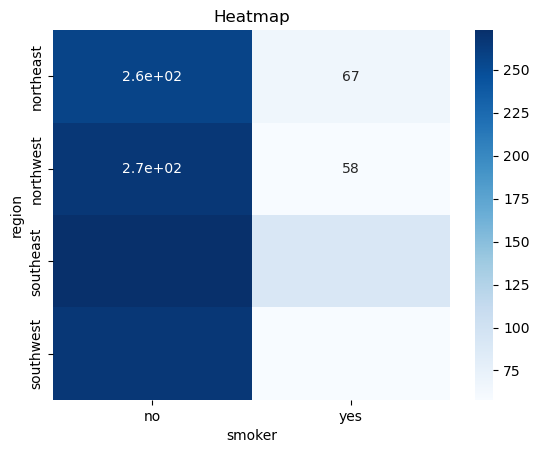

In [20]:
sns.heatmap(contingency_table, annot=True, cmap='Blues')
plt.title('Heatmap')
plt.show()


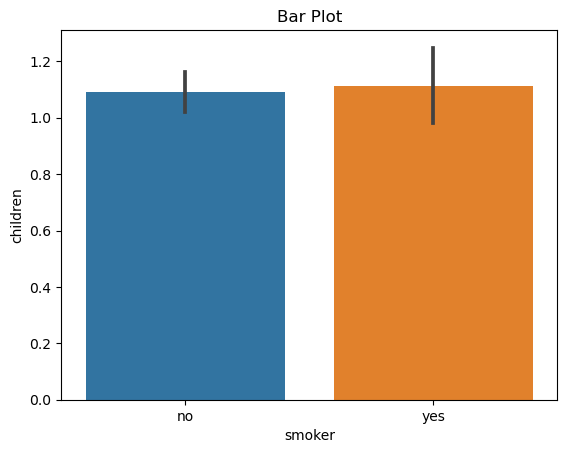

In [21]:
#exploring the relationship between the number of children feature and the smoker feature 

sns.barplot(data=df, x='smoker', y='children')
plt.title('Bar Plot')
plt.show()


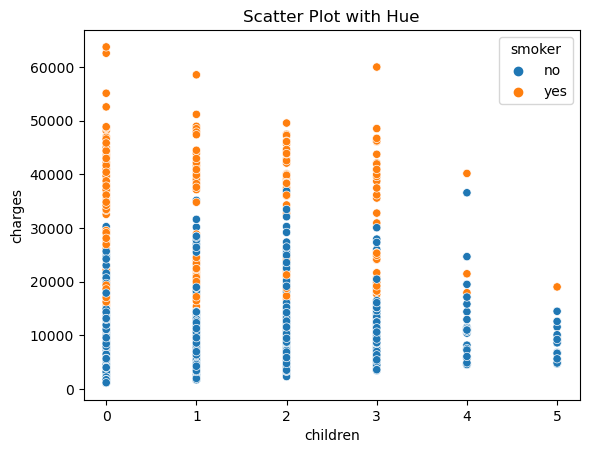

In [22]:
#bivariate analysis of the number of children feature Vs the medical claim charges feature Vs the smoker feature

# Scatter plot with hue
sns.scatterplot(data=df, x='children', y='charges', hue='smoker')
plt.title('Scatter Plot with Hue')
plt.show()



#### observation
- state down your observtaions from the bivariate analysis

### Multivariate Analaysis

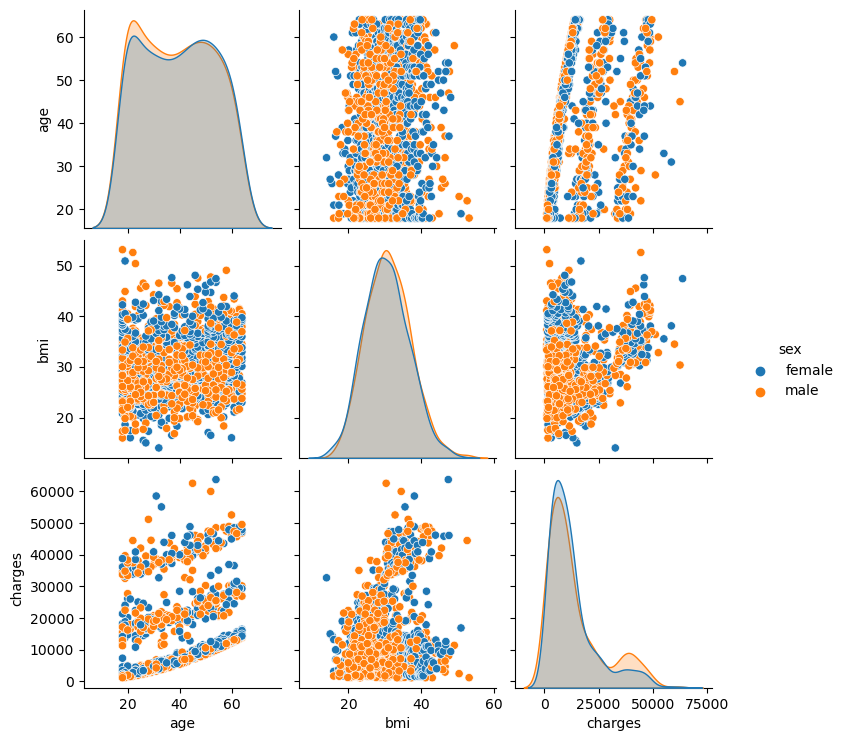

In [23]:
#use a pairplot to explore the relationship between the nummerical features in the dataset
sns.pairplot(df, vars=['age','bmi','charges'], hue='sex')
plt.show()

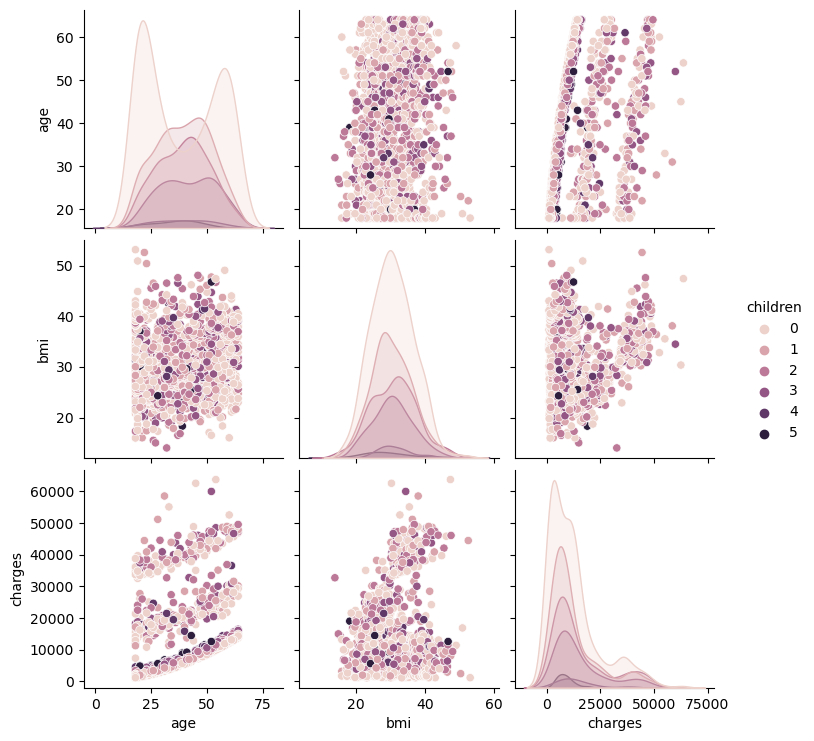

In [24]:
sns.pairplot(df, vars=['age','bmi','charges'], hue='children')
plt.show()

In [25]:

import warnings
warnings.filterwarnings('ignore')


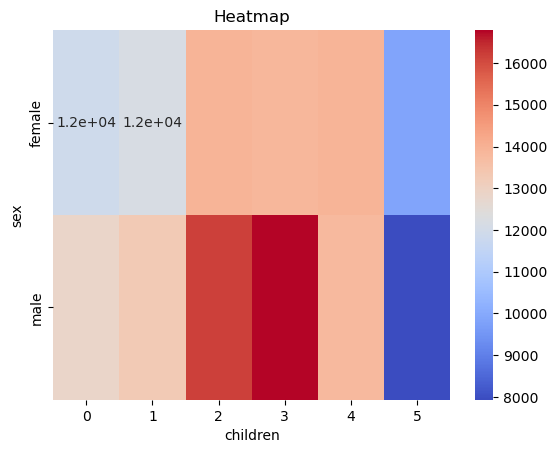

In [26]:
## heatmeap to see the correlation between features

# Pivot table for heatmap
pivot_table = df.pivot_table(values='charges', index='sex', columns='children')

# Heatmap
sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title('Heatmap')
plt.show()


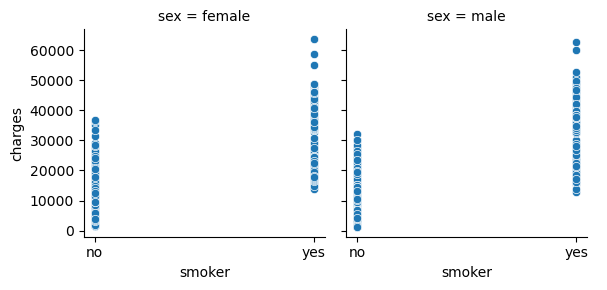

In [27]:
#exploring the relationship between the sex vs smoker vs charges features
g = sns.FacetGrid(df, col='sex')
g.map_dataframe(sns.scatterplot, x='smoker', y='charges')
g.add_legend()
plt.show()


**observations**
- state down your observations from the multivariate analysis

